In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path("..").resolve().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
batting = pd.read_csv(PROCESSED_DIR / "batting_features_final_v2.csv")
bowling = pd.read_csv(PROCESSED_DIR / "bowling_metrics.csv")
playing_xi = pd.read_csv(PROCESSED_DIR / "final_playing_xi.csv")

In [3]:
selected_openers = playing_xi[
    playing_xi["role"] == "Opener"
]["player"]

batting["group"] = batting["batsman"].apply(
    lambda x: "Selected Opener" if x in selected_openers else "Other Batters"
)

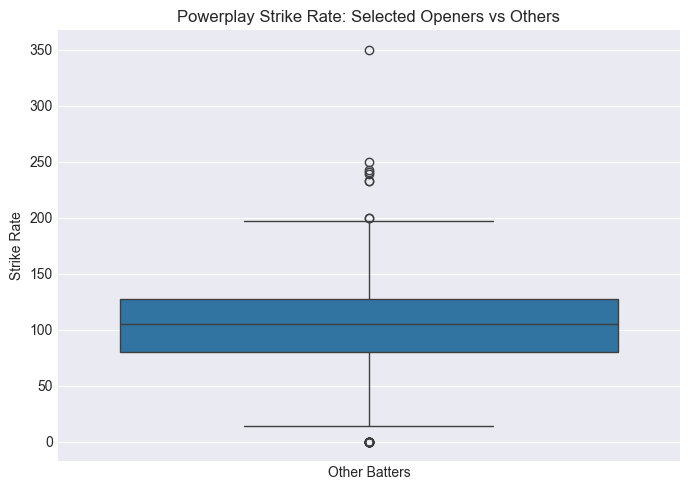

In [4]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=batting,
    x="group",
    y="Powerplay"
)

plt.title("Powerplay Strike Rate: Selected Openers vs Others")
plt.xlabel("")
plt.ylabel("Strike Rate")
plt.tight_layout()
plt.show()

In [5]:
selected_death = playing_xi[
    playing_xi["role"] == "Death Bowler"
]["player"]

bowling["group"] = bowling["bowler"].apply(
    lambda x: "Selected Death Bowler" if x in selected_death else "Other Bowlers"
)

In [7]:
# Create economy columns

bowling["powerplay_economy"] = bowling["Powerplay_y"] / (bowling["Powerplay_x"] / 6)

bowling["middle_overs_economy"] = bowling["Middle_y"] / (bowling["Middle_x"] / 6)

bowling["death_overs_economy"] = bowling["Death_y"] / (bowling["Death_x"] / 6)

# Replace infinity values
bowling = bowling.replace([float("inf"), -float("inf")], 0)

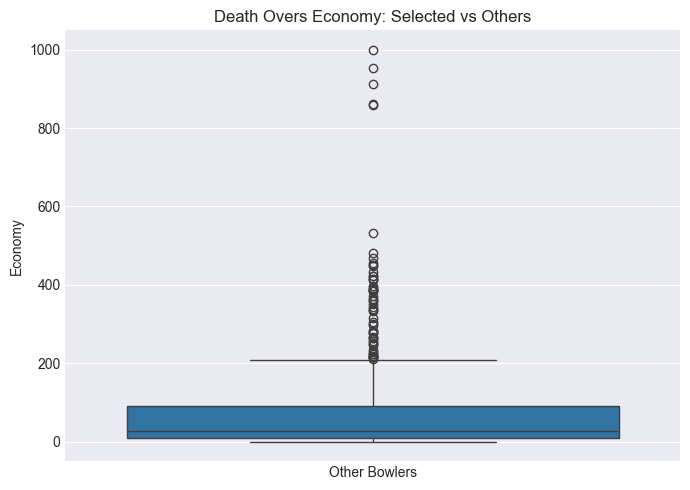

In [8]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=bowling,
    x="group",
    y="death_overs_economy"
)

plt.title("Death Overs Economy: Selected vs Others")
plt.xlabel("")
plt.ylabel("Economy")
plt.tight_layout()
plt.show()

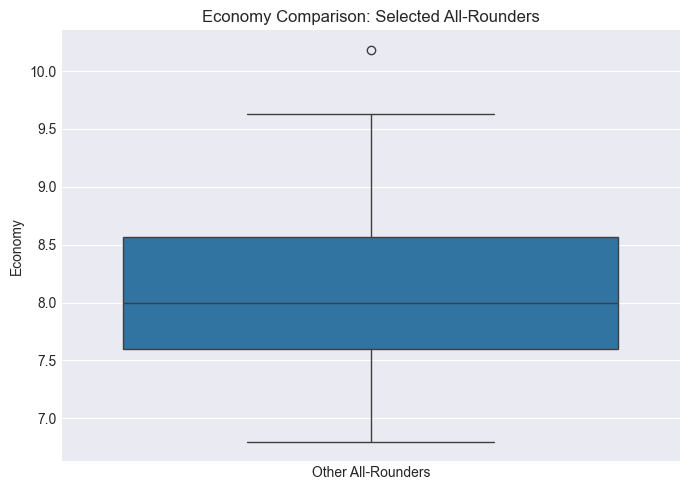

In [9]:
all_rounders = pd.read_csv(PROCESSED_DIR / "all_rounders.csv")

selected_ar = playing_xi[
    playing_xi["role"] == "All-Rounder"
]["player"]

all_rounders["group"] = all_rounders["player"].apply(
    lambda x: "Selected All-Rounder" if x in selected_ar else "Other All-Rounders"
)

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=all_rounders,
    x="group",
    y="economy"
)

plt.title("Economy Comparison: Selected All-Rounders")
plt.xlabel("")
plt.ylabel("Economy")
plt.tight_layout()
plt.show()